# Explanation
Example:Piston assembly strength test
target:Piston limit of tension required > 900kgf
1) Piston diameter(mm) :14.9, 15.2, 15.4
2) Piston Heigh (mm) :11.5, 11.6, 11.7
3) Piston Chamfer(mmdegree):150, 1.530, 130
4) Oil pressure (kgf/mm^2) :15, 17,20

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import numpy as np
data = {'Diameter':[15.2,15.2,15.2,15.4,15.4,15.4,14.9,14.9,14.9],
        'Heigh':[11.5,11.7,11.6,11.5,11.7,11.6,11.5,11.7,11.6],
        'Chamfer':['1*50','1.5*30','1*30','1.5*30','1*30','1*50','1*30','1*50','1.5*30'],
        'Oil_pressure':[15,17,20,20,15,17,17,20,15]    
}
df = pd.DataFrame(data)
df


,Diameter,Heigh,Chamfer,Oil_pressure
0,15.2,11.5,1*50,15
1,15.2,11.7,1.5*30,17
2,15.2,11.6,1*30,20
3,15.4,11.5,1.5*30,20
4,15.4,11.7,1*30,15
5,15.4,11.6,1*50,17
6,14.9,11.5,1*30,17
7,14.9,11.7,1*50,20
8,14.9,11.6,1.5*30,15


# add Breakaway data

Breakaway : from experiment


In [2]:
df['Breakaway'] = [856,950,908,877,972,898,802,1029,926]
df

,Diameter,Heigh,Chamfer,Oil_pressure,Breakaway
0,15.2,11.5,1*50,15,856
1,15.2,11.7,1.5*30,17,950
2,15.2,11.6,1*30,20,908
3,15.4,11.5,1.5*30,20,877
4,15.4,11.7,1*30,15,972
5,15.4,11.6,1*50,17,898
6,14.9,11.5,1*30,17,802
7,14.9,11.7,1*50,20,1029
8,14.9,11.6,1.5*30,15,926


# Transfomer la variable catégorielle Chamfer une variable numérique

In [3]:
sub_df = pd.DataFrame(df)
sub_df['Chamfer'] = sub_df.Chamfer.map(lambda x:1 if x=='1*50' else x)
sub_df['Chamfer'] = sub_df.Chamfer.map(lambda x:2 if x=='1.5*30' else x)
sub_df['Chamfer'] = sub_df.Chamfer.map(lambda x:3 if x=='1*30' else x)
sub_df

,Diameter,Heigh,Chamfer,Oil_pressure,Breakaway
0,15.2,11.5,1,15,856
1,15.2,11.7,2,17,950
2,15.2,11.6,3,20,908
3,15.4,11.5,2,20,877
4,15.4,11.7,3,15,972
5,15.4,11.6,1,17,898
6,14.9,11.5,3,17,802
7,14.9,11.7,1,20,1029
8,14.9,11.6,2,15,926


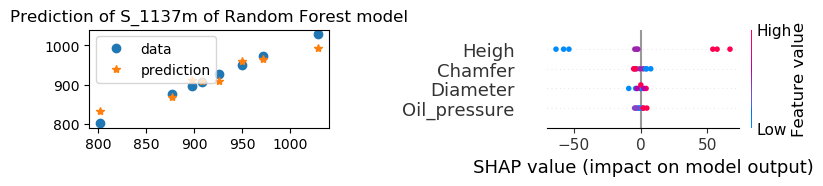

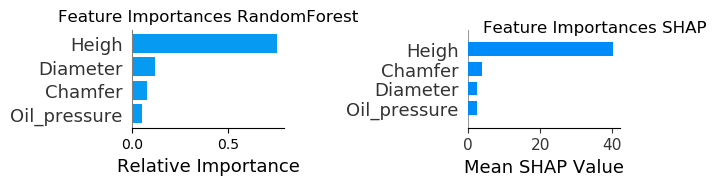

In [4]:
y = sub_df['Breakaway']
X = sub_df[["Diameter","Heigh", "Chamfer","Oil_pressure"]]
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 100, random_state = 0)
Score=cross_val_score(model, X , y, cv=5, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
model.fit(X, y) 
##### SHAP explaination
import shap
shap_values = shap.TreeExplainer(model).shap_values(X)
#### Visualisation 
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)
plt.subplot(2, 2, 1)
### Visualisation data predict
#x=y
plt.plot (y.iloc[1:9],y.iloc[1:9,], 'o',label="data")  #permet de tracer le graphique y = f(x) avec des croix bleues.
plt.plot(y.iloc[1:9],model.predict(X.iloc[1:9,]) , '*',label="prediction")
plt.title ("Prediction of S_1137m of Random Forest model") # donne un titre au graphique
plt.legend(loc='upper left')
plt.subplot(2, 2, 2)
shap.summary_plot(shap_values, X)             
## feature importance RandomForest
plt.subplot(2, 2, 3)
features = X.columns
plt.title('Feature Importances RandomForest')
plt.barh(range(len(indices)), importances[indices], color='#069AF3', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices],fontsize=13,color ='0.2')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_color('grey')
plt.tick_params(left = False)
plt.xlabel('Relative Importance',fontsize=13) 
## feature importance SHAP
plt.subplot(2, 2, 4)
shap.summary_plot(shap_values, X, plot_type="bar",show=0,sort=True)  
plt.xlabel('Mean SHAP Value')
plt.suptitle("Feature Importances SHAP",y=0.55,x=0.75)
plt.show()

In [ ]:
conda uninstall llvmlite

Solving environment: - 